# Day 5 — Scikit-learn Pipelines & Tuned Mini-Project

Today I bring together the main ideas from Week 4 into one complete machine learning workflow.

The goal is not only to train a model and get a score. The goal is to build the workflow in a clean and professional way so that preprocessing, cross-validation, hyperparameter tuning, and final evaluation all happen without leaking information from the test data.

In this notebook I will use the Titanic dataset again because I already know the problem and the features. This lets me focus on the new ideas from Day 5:

- `Pipeline`
- `ColumnTransformer`
- leak-free preprocessing
- cross-validation inside a pipeline
- `GridSearchCV` on the whole workflow
- final evaluation on an untouched test set


## 1. Imports

I will use pandas for working with the dataset and Scikit-learn for preprocessing, pipelines, model tuning, and evaluation.

One important change from the previous days is that missing-value handling, scaling, and categorical encoding will now be placed inside the pipeline instead of being applied manually before model training.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

## 2. Load the Dataset

I will use the same Titanic training dataset from the previous weeks.

The target is `Survived`, where:

- `0` means the passenger did not survive.
- `1` means the passenger survived.


In [2]:
df = pd.read_csv("../../week1/day4/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Quick Data Check

Before building the model, I want to quickly inspect the shape of the dataset, the column names, and the missing values.

This is not a full EDA because I already explored this dataset before. The goal here is only to confirm what preprocessing the pipeline will need.


In [3]:
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print(df.isna().sum().sort_values(ascending=False))

Shape: (891, 12)

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64


The Titanic dataset contains a mix of numeric and categorical columns.

It also contains missing values, especially in columns such as `Age`, `Cabin`, and `Embarked`.

Instead of filling these missing values before the split, I will let the pipeline handle them. This is safer because every preprocessing step will learn only from the training data used in that step.


## 4. Feature Engineering

I will create one useful feature that I already worked with in Day 4:

`FamilySize = SibSp + Parch + 1`

This represents the total number of family members traveling together, including the passenger.

This feature is created directly from values in the same row, so it does not require learning information from the rest of the dataset.


In [4]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

## 5. Define Features and Target

Some columns are not useful for this model in their original form.

I will remove:

- `PassengerId`
- `Name`
- `Ticket`
- `Cabin`

The remaining columns will be passed to the pipeline in their original form. I will not manually scale, fill, or one-hot encode them before the split.


In [5]:
target = "Survived"

X = df.drop(columns=[target, "PassengerId", "Name", "Ticket", "Cabin"])
y = df[target]

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,3,male,22.0,1,0,7.2500,S,2
1,1,female,38.0,1,0,71.2833,C,2
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,2
4,3,male,35.0,0,0,8.0500,S,1


## 6. Train/Test Split

The test set must stay untouched while I build and tune the model.

I will use:

- 80% for training and cross-validation
- 20% for the final test

I also use `stratify=y` so the survival class distribution stays similar in both sets.

The test set will not be used for choosing hyperparameters.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print()
print("Training class distribution:")
print(y_train.value_counts(normalize=True))
print()
print("Test class distribution:")
print(y_test.value_counts(normalize=True))

Training shape: (712, 8)
Test shape: (179, 8)

Training class distribution:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Test class distribution:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


## 7. Separate Numeric and Categorical Columns

Different types of data need different preprocessing.

For numeric features I will:

1. fill missing values using the median
2. scale the values using `StandardScaler`

For categorical features I will:

1. fill missing values using the most frequent value
2. convert categories into numeric columns using `OneHotEncoder`

`ColumnTransformer` allows me to apply these two preprocessing workflows to different groups of columns inside one object.


In [7]:
numeric_cols = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize"
]

categorical_cols = [
    "Pclass",
    "Sex",
    "Embarked"
]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
Categorical columns: ['Pclass', 'Sex', 'Embarked']


## 8. Build the Numeric Preprocessing Pipeline

For numeric columns, I first replace missing values with the median.

Then I scale the numeric features.

Random Forest does not require scaling in the same way that KNN or Logistic Regression does, but including the scaler here is useful because it demonstrates how numeric preprocessing can be safely placed inside a reusable pipeline. It also makes the preprocessing block easy to reuse with other models later.


In [8]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

## 9. Build the Categorical Preprocessing Pipeline

Categorical columns cannot be passed directly to most Scikit-learn models.

I will fill missing categorical values using the most common category and then apply one-hot encoding.

`handle_unknown="ignore"` is useful because it prevents an error if a new category appears later in validation, test, or future data.


In [9]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

categorical_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto ac

## 10. Combine Both with ColumnTransformer

Now I can combine the numeric and categorical preprocessing into one transformer.

The `ColumnTransformer` will automatically send each group of columns to the correct preprocessing pipeline and then combine the transformed results.


In [10]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 11. Build the Full Machine Learning Pipeline

Now I will connect preprocessing and the model in one `Pipeline`.

The workflow becomes:

**Raw training data → preprocessing → Random Forest**

The important part is that calling `fit()` on this pipeline will fit every preprocessing step using only the training data provided at that moment.

During cross-validation, each fold gets its own fitted imputer, scaler, encoder, and model. This is what makes the workflow leak-free.


In [11]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

## 12. Baseline Cross-Validation

Before tuning the model, I want a baseline score.

I will evaluate the full pipeline using 5-fold stratified cross-validation and F1 score.

Using the pipeline here is important. The preprocessing is repeated correctly inside every fold instead of being fitted once on the complete training set.


In [12]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

baseline_scores = cross_val_score(
    pipe,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Baseline fold F1 scores:", baseline_scores)
print("Baseline mean F1:", baseline_scores.mean())
print("Baseline standard deviation:", baseline_scores.std())

Baseline fold F1 scores: [0.72727273 0.72727273 0.75471698 0.7027027  0.72      ]
Baseline mean F1: 0.7263930276760465
Baseline standard deviation: 0.01676840113039661


The mean F1 score gives me a more reliable estimate than looking at one validation split.

The standard deviation tells me how much the model performance changes across folds.

A smaller standard deviation usually means the model is behaving more consistently across different parts of the training data.


## 13. Hyperparameter Grid

Now I will tune the Random Forest.

Because the model is inside a pipeline step named `model`, its parameters must use the format:

`model__parameter_name`

The double underscore tells Scikit-learn to look inside the `model` step of the pipeline.


In [13]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [1, 2, 4]
}

param_grid

{'model__n_estimators': [100, 200, 300],
 'model__max_depth': [5, 10, None],
 'model__min_samples_leaf': [1, 2, 4]}

## 14. Tune the Entire Pipeline with GridSearchCV

`GridSearchCV` will now evaluate complete versions of the pipeline.

For every hyperparameter combination and every cross-validation fold, Scikit-learn will:

1. fit the numeric imputer on that fold's training portion
2. fit the scaler on that fold's training portion
3. fit the categorical imputer on that fold's training portion
4. fit the one-hot encoder on that fold's training portion
5. train the Random Forest
6. evaluate the result on that fold's validation portion

This is much safer than preprocessing the whole dataset before cross-validation.


In [14]:
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be availa

## 15. Best Pipeline

After the search finishes, I can inspect the best hyperparameters and the best mean cross-validation F1 score.

The selected model is chosen only from the training data and cross-validation results. The test set is still untouched.


In [15]:
print("Best parameters:")
print(grid.best_params_)
print()
print("Best cross-validation F1:")
print(grid.best_score_)

Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 100}

Best cross-validation F1:
0.7573329518063068


## 16. Inspect the Grid Search Results

The full results are stored in `cv_results_`.


In [16]:
results = pd.DataFrame(grid.cv_results_)

results_table = results[
    [
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_leaf",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

results_table.head(10)

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,mean_train_score,mean_test_score,std_test_score,rank_test_score
21,100,None,2,0.880978,0.757333,0.025906,1
14,300,10,2,0.872247,0.751078,0.022948,2
22,200,None,2,0.879213,0.750877,0.028173,3
13,200,10,2,0.872263,0.749868,0.017540,4
23,300,None,2,0.879763,0.748307,0.022609,5
11,300,10,1,0.939526,0.747730,0.022617,6
2,300,5,1,0.800261,0.746338,0.033958,7
1,200,5,1,0.797567,0.743702,0.034602,8
12,100,10,2,0.870860,0.742709,0.023491,9
0,100,5,1,0.800639,0.742541,0.035696,10


The `mean_train_score` and `mean_test_score` columns are especially useful when thinking about bias and variance.

If the training score is very high but the validation score is clearly lower, the model may be overfitting.

If both are low, the model may be underfitting.

The goal is not simply to maximize the training score. I want strong and stable validation performance that is likely to generalize to unseen data.


## 17. Evaluate Once on the Test Set

Now that model selection is complete, I can finally use the test set.

`grid.best_estimator_` is the complete best pipeline, including preprocessing and the tuned Random Forest.

I do not need to manually transform the test set. Calling `predict()` on the pipeline automatically applies the fitted preprocessing before making predictions.


In [17]:
best_pipeline = grid.best_estimator_

y_pred = best_pipeline.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy)
print("Test F1:", test_f1)

Test Accuracy: 0.7988826815642458
Test F1: 0.7142857142857143


## 18. Classification Report

Accuracy gives the overall percentage of correct predictions, but it does not tell the whole story.

The classification report shows precision, recall, and F1 score for both classes.

For this Titanic problem, I pay special attention to the F1 score because it balances precision and recall.


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



## 19. Confusion Matrix

The confusion matrix makes the prediction errors easier to understand.

It shows:

- passengers correctly predicted as not survived
- passengers incorrectly predicted as survived
- passengers incorrectly predicted as not survived
- passengers correctly predicted as survived


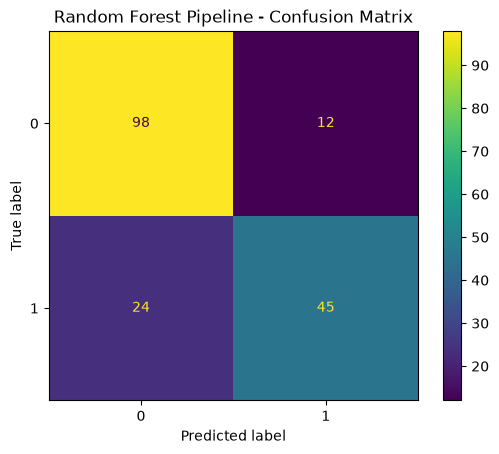

In [19]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Random Forest Pipeline - Confusion Matrix")
plt.show()

## 20. Compare Cross-Validation and Test Performance

A model should not only perform well during cross-validation. Its final test performance should also be reasonably close to the cross-validation result.

If the test score is much lower than the cross-validation score, that may mean the model did not generalize as well as expected.

A small difference is normal because the test set contains different examples.


In [20]:
comparison = pd.DataFrame({
    "Metric": [
        "Baseline CV F1",
        "Best CV F1",
        "Final Test F1"
    ],
    "Score": [
        baseline_scores.mean(),
        grid.best_score_,
        test_f1
    ]
})

comparison

,Metric,Score
0,Baseline CV F1,0.726393
1,Best CV F1,0.757333
2,Final Test F1,0.714286


## 22. Why This Pipeline Prevents Data Leakage

The main reason for using a pipeline is not only cleaner code.

It protects the workflow from accidental data leakage.

Without a pipeline, I might calculate missing-value statistics, scaling values, or category encodings using more data than I should.

With the pipeline, each preprocessing step is fitted at the correct time.

During cross-validation:

**fold training data → fit preprocessing → fit model**

and then:

**fold validation data → transform only → predict**

The validation portion never participates in learning the preprocessing values.

The same idea applies to the final test set.


## 23. Week 4 Connection

This notebook combines the main ideas from the whole week.

### Day 1
I learned why train, validation, and test data should have separate roles.

### Day 2
I learned how cross-validation gives a more stable evaluation than one validation split.

### Day 3
I learned about overfitting, underfitting, bias, variance, and generalization.

### Day 4
I worked with feature engineering and hyperparameter tuning using `GridSearchCV`.

### Day 5
I combined preprocessing, modeling, cross-validation, and tuning into one leak-free pipeline.

This is a much more professional way to structure a machine learning project because the workflow is reproducible, easier to maintain, and safer from leakage.


## Final Summary

The biggest lesson from Day 5 is that the model is only one part of a machine learning system.

The preprocessing steps are also part of the model-building process, so they should be trained and validated correctly.

The final workflow in this notebook is:

**Raw Data → Train/Test Split → Feature Engineering → ColumnTransformer → Pipeline → GridSearchCV → Cross-Validation → Best Pipeline → Final Test Evaluation**

The most important ideas I learned are:

- `Pipeline` combines preprocessing and modeling into one object.
- `ColumnTransformer` applies different preprocessing to numeric and categorical features.
- preprocessing should be fitted only on training data.
- cross-validation should evaluate the complete workflow, not only the final model.
- `GridSearchCV` can tune model parameters inside a pipeline using names such as `model__max_depth`.
- the test set should be used only after all model-selection decisions are complete.
- a leak-free workflow gives a more trustworthy estimate of generalization performance.

This notebook represents the complete Week 4 workflow and is much closer to how a real machine learning project should be organized.
